Phase no 1: Data Understanding

- Importing libraries

In [386]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

- Loading Dataset

In [387]:
dataset = pd.read_csv('customer_dataset.csv')

- checking top 2 rows of dataset

In [388]:
dataset.head(2)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
0,CUST-1001,58,Male,New York,Premium,92.00,15,2,3,Daily,2026-03-26,1,1
1,CUST-1002,20,Male,Los Angeles,Basic,14.65,39,1,0,Weekly,2026-03-29,5,1


- checking bottom 2 rows of dataset

In [389]:
dataset.tail(2)

,Customer ID,Age,Gender,City,Subscription Type,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Login Frequency,Last Activity Date,Satisfaction Score,Churn Status
1498,CUST-2499,43,Male,Philadelphia,Premium,136.89,3,2,0,Bi-weekly,2026-04-09,2,0
1499,CUST-2500,21,Other,Chicago,Standard,32.56,5,1,2,Weekly,2026-06-07,3,0


- Checking null values in dataset if any

In [390]:
dataset.isnull().sum()

Customer ID                  0
Age                          0
Gender                       0
City                         0
Subscription Type            0
Monthly Spending             0
Tenure                       0
Number of Purchases          0
Customer Support Requests    0
Login Frequency              0
Last Activity Date           0
Satisfaction Score           0
Churn Status                 0
dtype: int64

- Checking duplicates in dataset and removing if any

In [391]:
print(f"The duplicates in the dataset is: {dataset.duplicated().sum()}")

The duplicates in the dataset is: 0


- Checking outliers in dataset

In [392]:
target_column = 'Churn Status'

q1 = dataset['Churn Status'].quantile(0.25)
q3 = dataset['Churn Status'].quantile(0.75)

iqr = q3-q1

lower_limit = q1 - (1.5 *iqr)
higher_limit = q3 + (1.5 *iqr)

outliers = dataset[(dataset[target_column]<lower_limit)| (dataset[target_column]>higher_limit)]
print(f'Total outlier in the {target_column} is: {len(outliers)}')

Total outlier in the Churn Status is: 338


- Encode categorical variables

In [393]:
dataset = dataset.drop(columns=['Customer ID'])

dataset['Last Activity Date'] = pd.to_datetime(dataset['Last Activity Date'])

categorical_cols = dataset.select_dtypes(include=['object']).columns.tolist()

dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first=True)
dataset.head(4)

,Age,Monthly Spending,Tenure,Number of Purchases,Customer Support Requests,Last Activity Date,Satisfaction Score,Churn Status,Gender_Male,Gender_Other,...,City_Philadelphia,City_Phoenix,City_San Antonio,City_San Diego,City_San Jose,Subscription Type_Premium,Subscription Type_Standard,Login Frequency_Daily,Login Frequency_Monthly,Login Frequency_Weekly
0,58,92.00,15,2,3,2026-03-26,1,1,True,False,...,False,False,False,False,False,True,False,True,False,False
1,20,14.65,39,1,0,2026-03-29,5,1,True,False,...,False,False,False,False,False,False,False,False,False,True
2,55,23.96,22,5,0,2026-05-24,4,0,False,False,...,False,False,False,False,False,False,False,False,False,True
3,42,54.15,52,2,0,2026-04-13,2,0,True,False,...,True,False,False,False,False,False,True,False,True,False


- Distributing dataset into Train and testing data

In [394]:
X = dataset.drop(columns=['Churn Status'])  
Y = dataset['Churn Status']                

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [395]:
scaler = StandardScaler()

numerical_cols = ['Monthly Spending']

dataset[numerical_cols] = scaler.fit_transform(dataset[numerical_cols])

dataset[numerical_cols]

,Monthly Spending
0,0.790934
1,-1.159231
2,-0.924505
3,-0.163348
4,0.064318
...,...
1495,1.006751
1496,1.459563
1497,-0.400343
1498,1.922711


- Phase (2) : Exploratory Data Analysis

- Analyze Age Distribution column

In [396]:
display(dataset['Age'].describe())

count    1500.000000
mean       46.767333
std        16.657156
min        18.000000
25%        32.000000
50%        47.000000
75%        61.000000
max        75.000000
Name: Age, dtype: float64

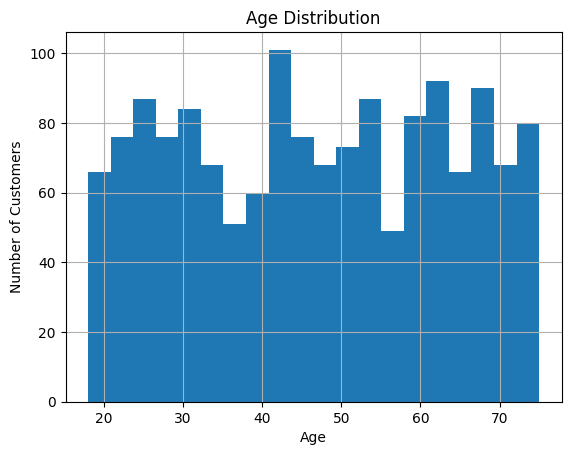

In [397]:
dataset['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

- Analyze Gender Distribution

In [398]:
gender_counts = categorical_col['Gender'].value_counts()

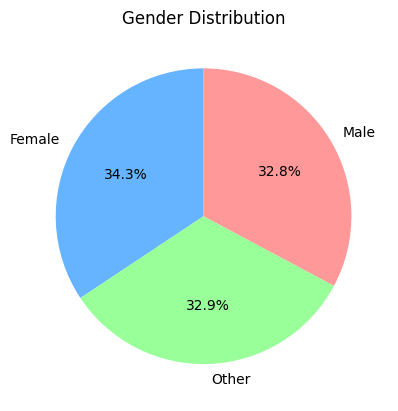

In [399]:
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,          
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66b3ff', '#99ff99', '#ff9999']  )
plt.title("Gender Distribution")
plt.show()



- Analyze Income Distribution

In [400]:
login_counts = categorical_col['Login Frequency'].value_counts()
display(login_counts)


Login Frequency
Daily        397
Monthly      382
Weekly       364
Bi-weekly    357
Name: count, dtype: int64

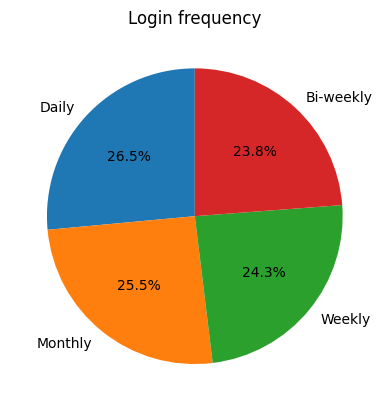

In [401]:
plt.pie(login_counts.values,
        labels = login_counts.index,
        autopct='%1.1f%%',
        startangle=90,
)
plt.title("Login frequency")
plt.show()

- Churn Distribution

In [402]:
churn_counts = dataset['Churn Status'].value_counts()
display(churn_counts)

Churn Status
0    1162
1     338
Name: count, dtype: int64

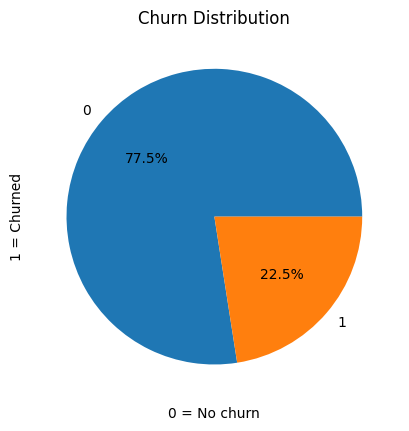

In [403]:
plt.pie(churn_counts.values,
        labels = churn_counts.index,
        autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.xlabel('0 = No churn')
plt.ylabel('1 = Churned')
plt.show()


- Correlational Matrix

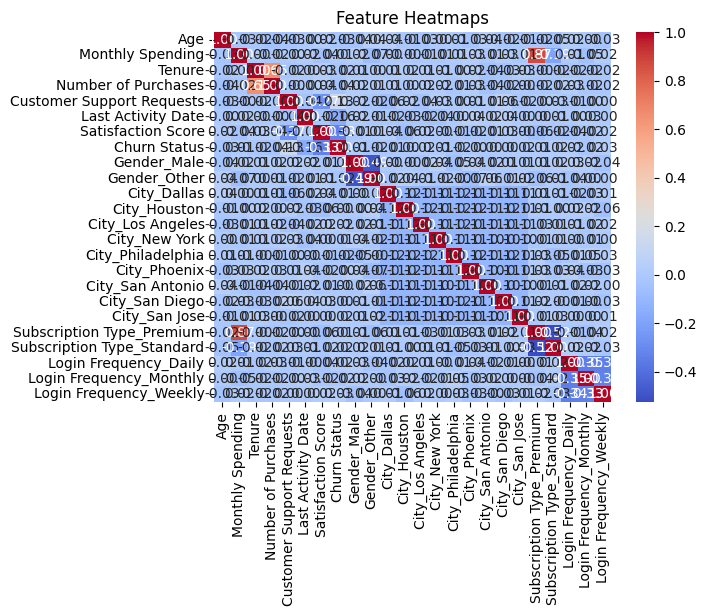

In [ ]:
# Use only numeric columns for the correlation heatmap
numeric_dataset = dataset.select_dtypes(include=['number'])

matrix = numeric_dataset.corr(method='pearson')
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Heatmaps')
plt.show()